In [1]:
from ioMicro import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_folder = r'E:\241207_WTC11_SFv7_T7_MERFISH_Analysis'

In [3]:
save_folder=r'E:\241207_WTC11_SFv7_T7_MERFISH_Analysis'#
#r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_AnalysisGFP'
ifov = 100
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
dec = decoder_simple(save_folder,fov,set_='')

In [4]:
dec.ncols = 3
dec.load_decoded()
dec.dist_best=np.load(dec.decoded_fl)['dist_best']

Loaded decoded: -1.3260002136230469


In [5]:
??dec.load_decoded

Signature: dec.load_decoded()
Docstring: <no docstring>
Source:   
    def load_decoded(self):
        import time
        start= time.time()
        self.decoded_fl = self.save_folder+os.sep+'decodedNew_'+self.fov.split('.')[0]+'--'+self.set_+'.npz'
        if not os.path.exists(self.decoded_fl):
            self.decoded_fl = self.save_folder+os.sep+'decoded_'+self.fov.split('.')[0]+'--'+self.set_+'.npz'
        if os.path.exists(self.decoded_fl):
            self.XH_pruned = np.load(self.decoded_fl)['XH_pruned']
            self.icodesN = np.load(self.decoded_fl)['icodesN']
            self.gns_names = np.load(self.decoded_fl)['gns_names']
            print("Loaded decoded:",start-time.time())
            return True
        else:
            return False
File:      c:\users\zgibbs\cellpose\wtc11_sfv7_december_2024\iomicro.py
Type:      method

In [6]:
??get_score_per_color

Signature: get_score_per_color(dec, include_dbits=False)
Docstring: <no docstring>
Source:   
def get_score_per_color(dec,include_dbits=False):
    H = np.nanmedian(dec.XH_pruned[...,-3],axis=1)
    #D = dec.XH_pruned[...,:3]-np.nanmean(dec.XH_pruned[...,:3],axis=1)[:,np.newaxis]
    #D = np.nanmean(np.linalg.norm(D,axis=-1),axis=-1)
    n1bits = dec.XH_pruned.shape[1]
    from itertools import combinations
    combs = np.array(list(combinations(np.arange(n1bits),2)))
    X = dec.XH_pruned[:,:,:3]
    D = np.nanmean(np.linalg.norm(X[:,combs][:,:,0]-X[:,combs][:,:,1],axis=-1),axis=1)
    
    if include_dbits:
        db = dec.dist_best
        score = np.array([H,-D,-db]).T
    else:
        score = np.array([H,-D]).T
    #score = np.sort(score,axis=0)
    return [np.sort(score[dec.XH_pruned[:,0,-2]==icol],axis=0) for icol in np.arange(dec.ncols)]
File:      c:\users\zgibbs\cellpose\wtc11_sfv7_december_2024\iomicro.py
Type:      function

In [7]:
dec.drift_fl 

'D:\\241207_WTC11_SFv7_HMERFISH_Analysis\\driftNew_Conv_zscan1_100--.pkl'

In [8]:
np.load(dec.drift_fl, allow_pickle = True)

[[[array([ -0.6012072, -15.794516 ,  -7.1039243], dtype=float32),
   array([ 0.5947494, 15.829344 ,  7.1416926], dtype=float32),
   array([ 0.61422205, 15.724324  ,  7.0278077 ], dtype=float32),
   262,
   130],
  [array([ 5.493981, 17.547733, 20.924192], dtype=float32),
   array([ -5.493981, -17.547733, -20.924192], dtype=float32),
   array([ -8.336562, -17.807676, -20.980482], dtype=float32),
   37,
   27],
  [array([ 0.10505193,  5.72758   , 11.438527  ], dtype=float32),
   array([ -0.09943758,  -5.711954  , -11.465035  ], dtype=float32),
   array([ -0.11781549,  -5.7631035 , -11.378263  ], dtype=float32),
   316,
   139],
  [array([0.05868546, 0.94497895, 5.6295676 ], dtype=float32),
   array([-0.0364834, -0.9409471, -5.6276083], dtype=float32),
   array([-0.10758804, -0.9538595 , -5.633883  ], dtype=float32),
   337,
   153],
  [array([0.06276658, 3.9556212 , 3.8728373 ], dtype=float32),
   array([-0.06935018, -3.92371   , -3.8679333 ], dtype=float32),
   array([-0.0478975, -4.027

In [85]:
scoresRef = get_score_per_color(dec)

In [88]:
len(scoresRef[0])

68614

Loaded decoded: -1.3450002670288086


NameError: name 'Xh0' is not defined

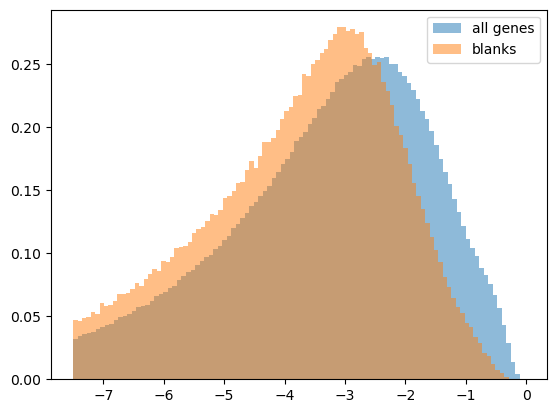

In [21]:
save_folder=r'E:\241207_WTC11_SFv7_T7_MERFISH_Analysis'#
#r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_AnalysisGFP'
ifov = 100
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
#save_folder =r'\\merfish19\merfish19\20240422_R136BICAN2kgene\MERFISHPlate3_4\AnalysisBB_P34_bkremove'
#save_folder =r'R:\Roy\2000gnMERFISH_DCBB_5_9_2024\MERFISH_AnalysisP5P6'
save_fl_ref = r'E:\241207_WTC11_SFv7_T7_MERFISH_Analysis\scores_ref.pkl'
dec = decoder_simple(save_folder,fov,set_='')
dec.ncols = 3
dec.load_decoded()
dec.dist_best=np.load(dec.decoded_fl)['dist_best']
if True:
    scoresRef = get_score_per_color(dec,include_dbits=True)
    pickle.dump(scoresRef,open(r'E:\241207_WTC11_SFv7_T7_MERFISH_Analysis\scoresRef.pkl','wb'))
else:
    scoresRef = pickle.load(open(r'E:\241207_WTC11_SFv7_T7_MERFISH_Analysis\scoresRef.pkl','rb'))
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-7.5,include_dbits=True)

Xh0_ = Xh0[(Xh0[:,-2]>0.6)&(Xh0[:,-1]>np.exp(9.5))]### Threshild based on quality of spot
Xh1_ = Xh1[(Xh1[:,-2]>0.6)&(Xh1[:,-1]>np.exp(9.5))]
X0 = Xh0_[:,:3]
X1 = Xh1_[:,:3]
from scipy.spatial import KDTree
dists,inds = KDTree(X0).query(X1)
X1F = Xh1_[(dists<2)][:,[0,1,2,-1]]
if False:
    plt.hist(np.log(Xh0_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh0_[inds[(dists<2)],-1]),density=True,bins=30,alpha=0.5)
    plt.hist(np.log(Xh1_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh1_[dists<1.5,-1]),density=True,bins=30,alpha=0.5)
if False:
    imGFP = read_im(r'D:\241207_WTC11_SFv7\H17_MER'+os.sep+dec.fov)
    import napari
    V = napari.view_image(imGFP)
    V.add_points(X1F[:,:3],face_color=[0,0,0,0],edge_color='r')
### apply drift
drifts,flds,fov_,fl_ref = np.load(dec.drift_fl,allow_pickle=True)
from worker_ZaneWTC_HGFP import *
fl = r'D:\241207_WTC11_SFv7\H17_MER'+os.sep+dec.fov
drift = get_best_translation_pointsV2(fl,fl_ref,save_folder,'',resc=5)
X1FD = X1F.copy()
X1FD[:,:3]=X1F[:,:3]+drift[0]

X_MERFISH = np.nanmean(dec.XH_pruned[:,:,:3],axis=1)
tree = KDTree(X_MERFISH)
dist,indMER = tree.query(X1FD[:,:3],workers=10)

keepMER = indMER[dist<2]

XH_pruned = dec.XH_pruned[keepMER]
scoreA = dec.scoreA[keepMER]
icodesN = dec.icodesN[keepMER]
ibad = [ign for ign,gn in enumerate(dec.gns_names) if 'blank' in gn]
isbad = np.in1d(icodesN,ibad)
isgood=~isbad

plt.hist(scoreA[isbad],density=True,bins=100)
plt.hist(scoreA[isgood],density=True,bins=100,alpha=0.7);

th=-2 ## this is your final decided threshold
np.sum(dec.scoreA>th),np.sum(scoreA>th)
X1FD.shape,scoreA.shape
print("Fraction of GFP decoded above confidence:",np.sum(scoreA>th)/len(X1FD))#,len(scoreA)/len(X1FD)

XH_prunedf = XH_pruned[scoreA>th]
scoreAf = scoreA[scoreA>th]
icodesNf = icodesN[scoreA>th]
dist_bestf = dec.dist_best[keepMER][scoreA>th]
bigSpot = X1FD[dist<2][scoreA>th][:,-1]>np.exp(12)
#XH_prunedf = XH_pruned[scoreA>th]

_,cts = np.unique(list(icodesNf)+list(np.arange(len(dec.gns_names))),return_counts=True)
cts = cts-1
plt.figure()
plt.plot(ibad,cts[ibad])
igood = np.setdiff1d(np.arange(len(cts)),ibad)
plt.plot(igood,cts[igood])
plt.title(np.round(np.mean(cts[ibad])/np.mean(cts[igood]),2))

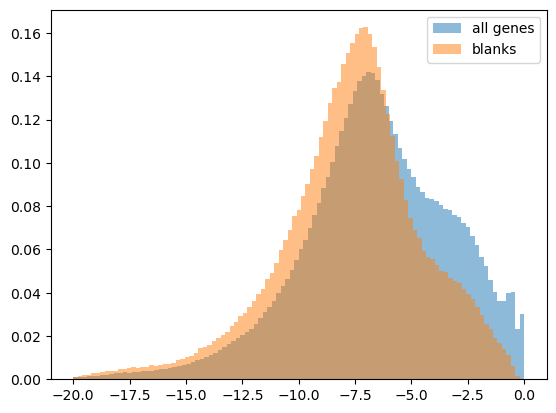

In [16]:
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-20,include_dbits=True)

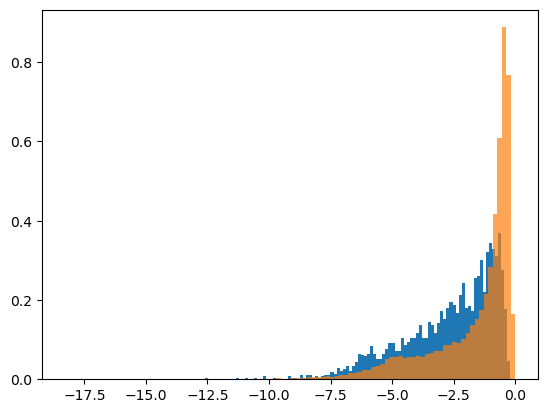

In [22]:
plt.hist(scoreA[isbad],density=True,bins=100)
plt.hist(scoreA[isgood],density=True,bins=100,alpha=0.7);

In [9]:
save_folder=r'E:\241207_WTC11_SFv7_T7_MERFISH_Analysis'
ifov = 30
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
#save_folder =r'\\merfish19\merfish19\20240422_R136BICAN2kgene\MERFISHPlate3_4\AnalysisBB_P34_bkremove'
#save_folder =r'R:\Roy\2000gnMERFISH_DCBB_5_9_2024\MERFISH_AnalysisP5P6'
save_fl_ref = r'E:\241207_WTC11_SFv7_T7_MERFISH_Analysis\scores_ref.pkl'
dec = decoder_simple(save_folder,fov,set_='')
dec.ncols = 3
dec.load_decoded()
dec.dist_best=np.load(dec.decoded_fl)['dist_best']

Loaded decoded: -1.495999813079834


In [101]:
scoresRef = get_score_per_color(dec)

In [113]:
dec.icodesN = dec.icodesN[keep]

In [118]:
dec.dist_best = dec.dist_best[keep]

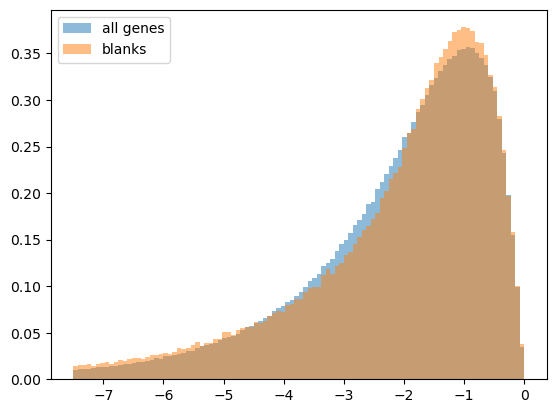

In [120]:
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-7.5,include_dbits=True)

# X_MERFISH = dec.XH_pruned[:,:,-3] > np.exp(9.5)

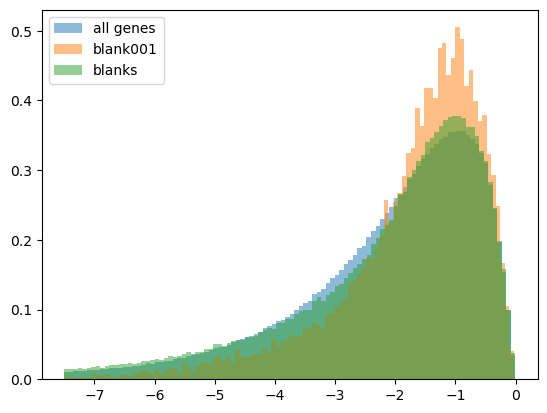

In [124]:
get_score_withRef(dec,scoresRef,plt_val=True,gene='blank001',iSs = None,th_min=-7.5,include_dbits=False)

# X_MERFISH = dec.XH_pruned[:,:,-3] > np.exp(9.5)

In [106]:
np.nanmedian(dec.XH_pruned[...,-3],axis=1).shape

(1081893,)

In [105]:
??get_score_withRef

Signature:
get_score_withRef(
    dec,
    scoresRef,
    plt_val=False,
    gene=None,
    iSs=None,
    th_min=-inf,
    include_dbits=False,
)
Docstring: <no docstring>
Source:   
def get_score_withRef(dec,scoresRef,plt_val=False,gene=None,iSs=None,th_min=-np.inf,include_dbits=False):
    H = np.nanmedian(dec.XH_pruned[...,-3],axis=1)
    #D = dec.XH_pruned[...,:3]-np.nanmean(dec.XH_pruned[...,:3],axis=1)[:,np.newaxis]
    #D = np.nanmean(np.linalg.norm(D,axis=-1),axis=-1)
    n1bits = dec.XH_pruned.shape[1]
    from itertools import combinations
    combs = np.array(list(combinations(np.arange(n1bits),2)))
    X = dec.XH_pruned[:,:,:3]
    D = np.nanmean(np.linalg.norm(X[:,combs][:,:,0]-X[:,combs][:,:,1],axis=-1),axis=1)
    
    if include_dbits:
        db = dec.dist_best
        score = np.array([H,-D,-db]).T
    else:
        score = np.array([H,-D]).T
    
    keep_color = [np.nanmedian(dec.XH_pruned[:,:,-2],axis=1)==icol for icol in np.arange(dec.ncols)]
    scoreA = np.zeros

In [16]:
def get_counts(icodesNf):
    _,cts = np.unique(list(icodesNf)+list(np.arange(len(dec.gns_names))),return_counts=True)
    cts = cts-1
    plt.figure()
    plt.plot(ibad,cts[ibad])
    igood = np.setdiff1d(np.arange(len(cts)),ibad)
    plt.plot(igood,cts[igood])
    plt.title(np.round(np.mean(cts[ibad])/np.mean(cts[igood]),2))
    return cts

In [92]:
h = dec.XH_pruned[:,:,-3]
keep = np.any(h > np.exp(9.5), axis=1)

In [93]:
h.shape

(2168096, 4)

In [94]:
len(keep)

2168096

In [95]:
new = dec.XH_pruned[keep]

In [97]:
OG_dec = dec.XH_pruned

In [98]:
dec.XH_pruned = new

In [99]:
dec.XH_pruned.shape

(1081893, 4, 10)

In [103]:
dec